implementar Q-lerning para el grid de 15x15 empleado en uno de los ejercicios anteriores

Forma de la tabla Q: (15, 15, 4)
Episodio   500 | Recompensa promedio:  -45.52 | Pasos promedio: 115.78 | Epsilon: 0.082
Episodio  1000 | Recompensa promedio:   71.20 | Pasos promedio:  29.49 | Epsilon: 0.050
Episodio  1500 | Recompensa promedio:   71.23 | Pasos promedio:  29.39 | Epsilon: 0.050
Episodio  2000 | Recompensa promedio:   71.29 | Pasos promedio:  29.42 | Epsilon: 0.050
Episodio  2500 | Recompensa promedio:   71.16 | Pasos promedio:  29.50 | Epsilon: 0.050
Episodio  3000 | Recompensa promedio:   71.11 | Pasos promedio:  29.50 | Epsilon: 0.050
Episodio  3500 | Recompensa promedio:   71.22 | Pasos promedio:  29.43 | Epsilon: 0.050
Episodio  4000 | Recompensa promedio:   71.27 | Pasos promedio:  29.46 | Epsilon: 0.050
Episodio  4500 | Recompensa promedio:   71.04 | Pasos promedio:  29.50 | Epsilon: 0.050
Episodio  5000 | Recompensa promedio:   71.36 | Pasos promedio:  29.35 | Epsilon: 0.050
Episodio  5500 | Recompensa promedio:   71.12 | Pasos promedio:  29.47 | Epsilon: 0.050

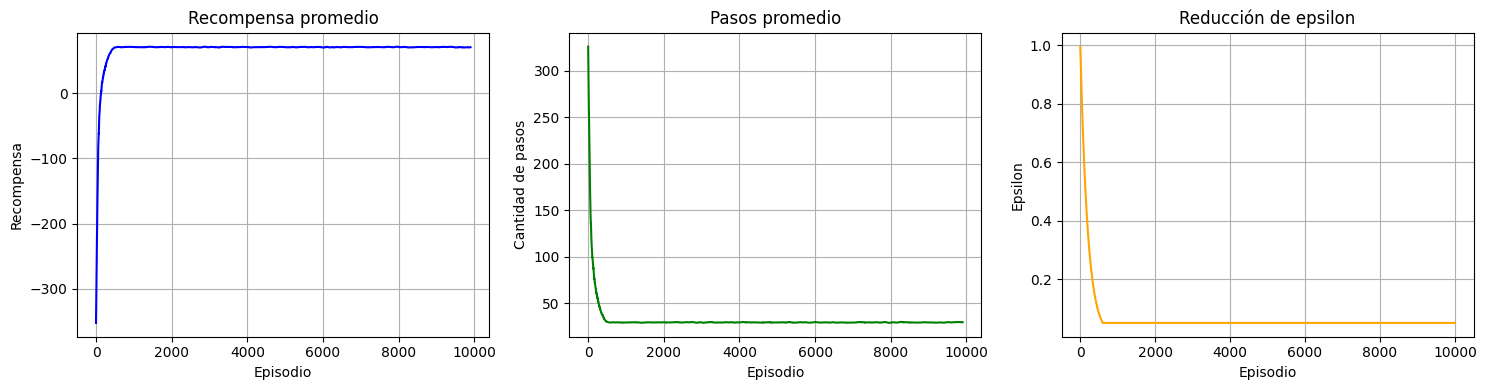

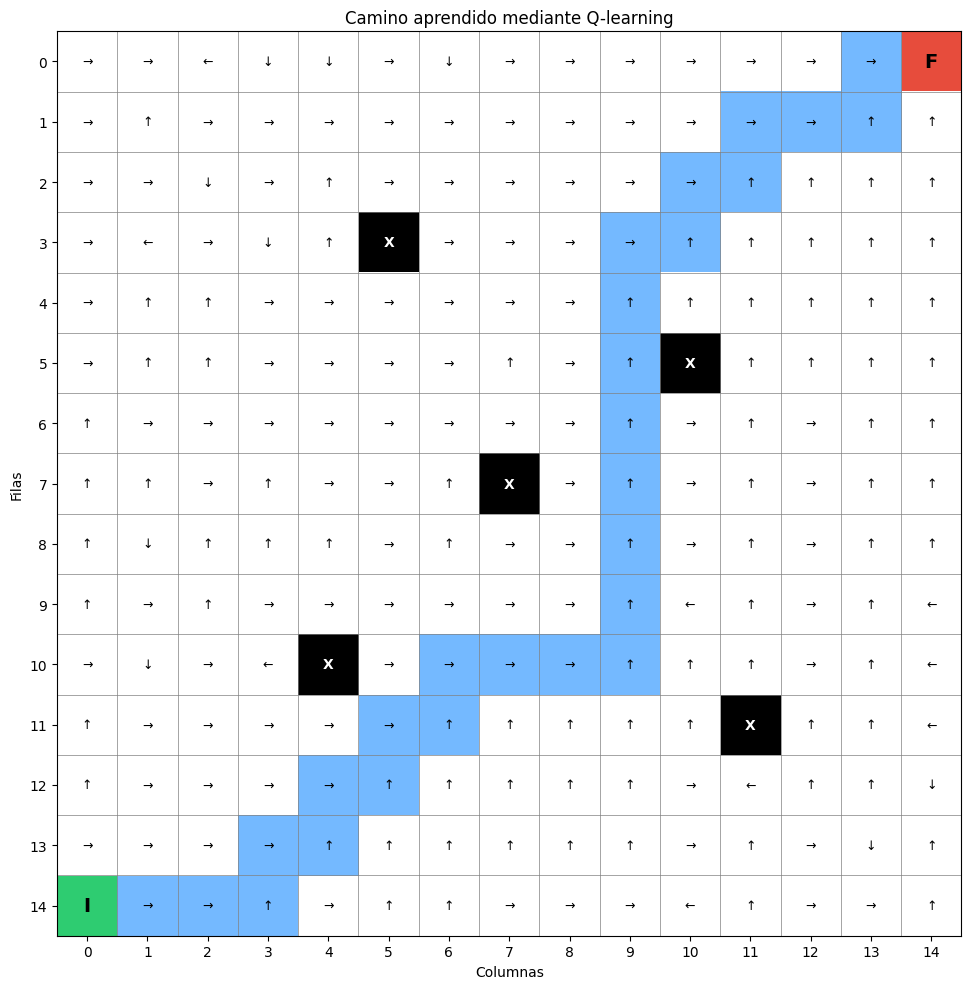

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


# ============================================================
# 1. CONFIGURACIÓN DEL GRIDWORLD
# ============================================================

FILAS = 15
COLUMNAS = 15

INICIO = (14, 0)
META = (0, 14)

OBSTACULOS = {
    (3, 5),
    (5, 10),
    (7, 7),
    (10, 4),
    (11, 11)
}

# Acciones disponibles
# 0 = arriba
# 1 = abajo
# 2 = izquierda
# 3 = derecha

ACCIONES = {
    0: (-1, 0),
    1: (1, 0),
    2: (0, -1),
    3: (0, 1)
}

FLECHAS = {
    0: "↑",
    1: "↓",
    2: "←",
    3: "→"
}

NOMBRES_ACCIONES = {
    0: "arriba",
    1: "abajo",
    2: "izquierda",
    3: "derecha"
}


# ============================================================
# 2. PARÁMETROS DE Q-LEARNING
# ============================================================

EPISODIOS = 10000
MAX_PASOS = 500

# Tasa de aprendizaje
ALPHA = 0.1

# Factor de descuento
GAMMA = 0.95

# Probabilidad inicial de explorar
EPSILON = 1.0

# Probabilidad mínima de explorar
EPSILON_MINIMO = 0.05

# Reducción de epsilon
EPSILON_DECAY = 0.995

# Recompensas
RECOMPENSA_META = 100
RECOMPENSA_MOVIMIENTO = -1
PENALIZACION_CHOQUE = -5

# Semilla para repetir resultados
random.seed(42)
np.random.seed(42)


# ============================================================
# 3. CREAR LA TABLA Q
# ============================================================

# Para cada posición existen cuatro valores Q,
# uno para cada dirección.

tabla_q = np.zeros(
    (FILAS, COLUMNAS, 4)
)

print("Forma de la tabla Q:", tabla_q.shape)


# ============================================================
# 4. FUNCIÓN PARA MOVER EL AGENTE
# ============================================================

def mover(estado, accion):
    """
    Ejecuta una acción y retorna:
    - siguiente estado
    - recompensa
    - si llegó a la meta
    """

    fila, columna = estado

    cambio_fila, cambio_columna = ACCIONES[accion]

    nueva_fila = fila + cambio_fila
    nueva_columna = columna + cambio_columna

    siguiente_estado = (
        nueva_fila,
        nueva_columna
    )

    # Verificar si el agente sale del tablero
    fuera_del_grid = not (
        0 <= nueva_fila < FILAS
        and
        0 <= nueva_columna < COLUMNAS
    )

    # Si choca con un borde o un obstáculo,
    # permanece en la misma posición
    if fuera_del_grid or siguiente_estado in OBSTACULOS:

        return (
            estado,
            PENALIZACION_CHOQUE,
            False
        )

    # Si llega a la meta
    if siguiente_estado == META:

        return (
            siguiente_estado,
            RECOMPENSA_META,
            True
        )

    # Movimiento normal
    return (
        siguiente_estado,
        RECOMPENSA_MOVIMIENTO,
        False
    )


# ============================================================
# 5. SELECCIONAR UNA ACCIÓN
# ============================================================

def seleccionar_accion(estado, epsilon):
    """
    Política epsilon-greedy.

    El agente explora con probabilidad epsilon
    y utiliza lo aprendido el resto del tiempo.
    """

    fila, columna = estado

    # Exploración: escoger una acción aleatoria
    if random.random() < epsilon:

        return random.randint(0, 3)

    # Explotación: escoger la acción con mayor Q
    return np.argmax(
        tabla_q[fila, columna]
    )


# ============================================================
# 6. ENTRENAR EL AGENTE
# ============================================================

def entrenar_agente():

    epsilon = EPSILON

    historial_recompensas = []
    historial_pasos = []
    historial_epsilon = []

    for episodio in range(1, EPISODIOS + 1):

        estado = INICIO

        recompensa_total = 0
        cantidad_pasos = 0

        for paso in range(MAX_PASOS):

            # Seleccionar acción
            accion = seleccionar_accion(
                estado,
                epsilon
            )

            # Ejecutar acción
            siguiente_estado, recompensa, terminado = mover(
                estado,
                accion
            )

            fila, columna = estado

            siguiente_fila, siguiente_columna = (
                siguiente_estado
            )

            # Valor Q actual
            q_actual = tabla_q[
                fila,
                columna,
                accion
            ]

            # Mejor valor Q del siguiente estado
            mejor_q_siguiente = np.max(
                tabla_q[
                    siguiente_fila,
                    siguiente_columna
                ]
            )

            # Si llegó a la meta, no hay recompensa futura
            if terminado:
                objetivo = recompensa
            else:
                objetivo = (
                    recompensa
                    + GAMMA * mejor_q_siguiente
                )

            # Fórmula de actualización de Q-learning
            tabla_q[
                fila,
                columna,
                accion
            ] = (
                q_actual
                + ALPHA * (objetivo - q_actual)
            )

            estado = siguiente_estado

            recompensa_total += recompensa
            cantidad_pasos += 1

            if terminado:
                break

        # Reducir la exploración
        epsilon = max(
            EPSILON_MINIMO,
            epsilon * EPSILON_DECAY
        )

        historial_recompensas.append(
            recompensa_total
        )

        historial_pasos.append(
            cantidad_pasos
        )

        historial_epsilon.append(
            epsilon
        )

        # Mostrar el progreso cada 500 episodios
        if episodio % 500 == 0:

            promedio = np.mean(
                historial_recompensas[-500:]
            )

            pasos_promedio = np.mean(
                historial_pasos[-500:]
            )

            print(
                f"Episodio {episodio:5d} | "
                f"Recompensa promedio: {promedio:7.2f} | "
                f"Pasos promedio: {pasos_promedio:6.2f} | "
                f"Epsilon: {epsilon:.3f}"
            )

    return (
        historial_recompensas,
        historial_pasos,
        historial_epsilon
    )


# ============================================================
# 7. OBTENER LA POLÍTICA APRENDIDA
# ============================================================

def obtener_politica():

    politica = {}

    for fila in range(FILAS):
        for columna in range(COLUMNAS):

            estado = (fila, columna)

            if estado in OBSTACULOS:
                continue

            if estado == META:
                continue

            mejor_accion = np.argmax(
                tabla_q[fila, columna]
            )

            politica[estado] = mejor_accion

    return politica


# ============================================================
# 8. OBTENER EL CAMINO APRENDIDO
# ============================================================

def obtener_mejor_camino(politica):

    estado = INICIO

    camino = [estado]
    acciones_camino = []

    estados_visitados = {estado}

    for _ in range(FILAS * COLUMNAS):

        if estado == META:
            return camino, acciones_camino

        accion = politica[estado]

        siguiente_estado, _, terminado = mover(
            estado,
            accion
        )

        acciones_camino.append(
            accion
        )

        if siguiente_estado in estados_visitados:

            print(
                "La política produjo un ciclo. "
                "Puede ser necesario aumentar los episodios."
            )

            return camino, acciones_camino

        camino.append(
            siguiente_estado
        )

        estados_visitados.add(
            siguiente_estado
        )

        estado = siguiente_estado

        if terminado:
            return camino, acciones_camino

    return camino, acciones_camino


# ============================================================
# 9. MOSTRAR EL APRENDIZAJE
# ============================================================

def promedio_movil(datos, ventana=100):

    return np.convolve(
        datos,
        np.ones(ventana) / ventana,
        mode="valid"
    )


def mostrar_aprendizaje(
    recompensas,
    pasos,
    epsilon
):

    plt.figure(figsize=(15, 4))

    # Recompensas
    plt.subplot(1, 3, 1)

    plt.plot(
        promedio_movil(recompensas),
        color="blue"
    )

    plt.title("Recompensa promedio")
    plt.xlabel("Episodio")
    plt.ylabel("Recompensa")
    plt.grid()

    # Cantidad de pasos
    plt.subplot(1, 3, 2)

    plt.plot(
        promedio_movil(pasos),
        color="green"
    )

    plt.title("Pasos promedio")
    plt.xlabel("Episodio")
    plt.ylabel("Cantidad de pasos")
    plt.grid()

    # Epsilon
    plt.subplot(1, 3, 3)

    plt.plot(
        epsilon,
        color="orange"
    )

    plt.title("Reducción de epsilon")
    plt.xlabel("Episodio")
    plt.ylabel("Epsilon")
    plt.grid()

    plt.tight_layout()
    plt.show()


# ============================================================
# 10. MOSTRAR EL CAMINO Y LA POLÍTICA
# ============================================================

def mostrar_grid(politica, camino):

    # Valores visuales:
    # 0 = espacio libre
    # 1 = obstáculo
    # 2 = camino
    # 3 = inicio
    # 4 = meta

    grid = np.zeros(
        (FILAS, COLUMNAS)
    )

    for obstaculo in OBSTACULOS:
        grid[obstaculo] = 1

    for posicion in camino[1:-1]:
        grid[posicion] = 2

    grid[INICIO] = 3
    grid[META] = 4

    colores = ListedColormap([
        "white",
        "black",
        "#74b9ff",
        "#2ecc71",
        "#e74c3c"
    ])

    fig, ax = plt.subplots(
        figsize=(10, 10)
    )

    ax.imshow(
        grid,
        cmap=colores,
        vmin=0,
        vmax=4
    )

    # Dibujar la política
    for fila in range(FILAS):
        for columna in range(COLUMNAS):

            estado = (fila, columna)

            if estado in OBSTACULOS:
                ax.text(
                    columna,
                    fila,
                    "X",
                    ha="center",
                    va="center",
                    color="white",
                    fontweight="bold"
                )

            elif estado == INICIO:
                ax.text(
                    columna,
                    fila,
                    "I",
                    ha="center",
                    va="center",
                    fontsize=14,
                    fontweight="bold"
                )

            elif estado == META:
                ax.text(
                    columna,
                    fila,
                    "F",
                    ha="center",
                    va="center",
                    fontsize=14,
                    fontweight="bold"
                )

            elif estado in politica:
                ax.text(
                    columna,
                    fila,
                    FLECHAS[politica[estado]],
                    ha="center",
                    va="center",
                    fontsize=9
                )

    # Líneas del grid
    ax.set_xticks(
        np.arange(-0.5, COLUMNAS, 1),
        minor=True
    )

    ax.set_yticks(
        np.arange(-0.5, FILAS, 1),
        minor=True
    )

    ax.grid(
        which="minor",
        color="gray",
        linewidth=0.5
    )

    ax.tick_params(
        which="minor",
        bottom=False,
        left=False
    )

    ax.set_xticks(range(COLUMNAS))
    ax.set_yticks(range(FILAS))

    ax.set_xlabel("Columnas")
    ax.set_ylabel("Filas")

    ax.set_title(
        "Camino aprendido mediante Q-learning"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 11. EJECUTAR EL PROGRAMA
# ============================================================

recompensas, pasos, valores_epsilon = entrenar_agente()

politica_aprendida = obtener_politica()

mejor_camino, acciones_camino = obtener_mejor_camino(
    politica_aprendida
)

print("\n" + "=" * 60)
print("RESULTADO FINAL")
print("=" * 60)

print("Inicio:", INICIO)
print("Meta:", META)
print("Obstáculos:", sorted(OBSTACULOS))

print(
    "Cantidad de movimientos:",
    len(mejor_camino) - 1
)

print("\nCamino aprendido:")

for numero, posicion in enumerate(mejor_camino):
    print(
        f"Paso {numero:02d}: {posicion}"
    )

print("\nDirecciones seguidas:")

for numero, accion in enumerate(acciones_camino):
    print(
        f"Movimiento {numero + 1:02d}: "
        f"{NOMBRES_ACCIONES[accion]}"
    )

mostrar_aprendizaje(
    recompensas,
    pasos,
    valores_epsilon
)

mostrar_grid(
    politica_aprendida,
    mejor_camino
)

## Comparación con los métodos anteriores

Al comparar Q-learning con la iteración de valores y la iteración de políticas, los tres métodos pueden encontrar un camino óptimo de 28 movimientos desde el punto inicial hasta la meta. La diferencia principal se encuentra en la manera como obtienen el resultado.

La iteración de valores encontró el camino en aproximadamente 29 iteraciones porque conoce las reglas, las recompensas y los posibles movimientos del entorno. Este método calcula directamente el mejor valor para cada posición hasta que los valores dejan de cambiar.

La iteración de políticas también utiliza toda la información del entorno, pero primero evalúa una política de direcciones y después modifica las decisiones que pueden mejorarse. Normalmente necesita pocas iteraciones, aunque cada una requiere evaluar completamente la política actual.

Q-learning necesitó una mayor cantidad de episodios porque inicialmente no conocía cuál era la mejor dirección desde cada posición. El agente tuvo que explorar el grid, recibir recompensas y penalizaciones y actualizar su tabla Q con la experiencia obtenida. Al finalizar el entrenamiento logró encontrar el mismo camino óptimo de 28 movimientos.

En conclusión, la iteración de valores y la iteración de políticas son más rápidas cuando se conocen completamente las reglas del entorno. Q-learning necesita más tiempo de entrenamiento, pero resulta más útil cuando el agente no conoce inicialmente el entorno y debe aprender mediante prueba, error y recompensas.
